**Iris Flower Classification Project.**

In [127]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

 **Data Loading and Preprocessing**

In [128]:
df = sns.load_dataset('iris')

In [129]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [130]:
from sklearn.preprocessing import LabelEncoder

In [131]:
le=LabelEncoder()

In [132]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [133]:
le = LabelEncoder()
df['species']=le.fit_transform(df['species'])

In [134]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [135]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2
149,5.9,3.0,5.1,1.8,2


**Exploratory Data Analysis (EDA)**

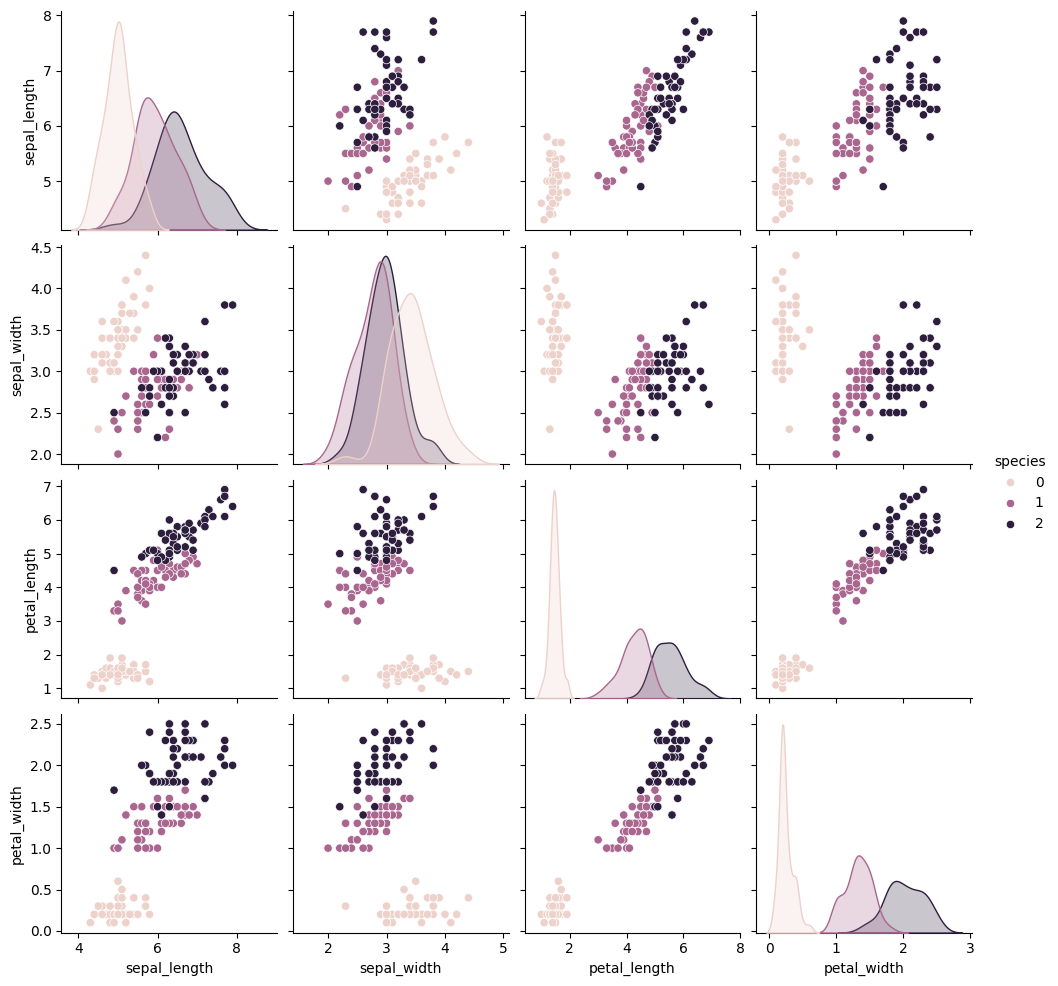

In [136]:
sns.pairplot(df, hue='species')
plt.show()

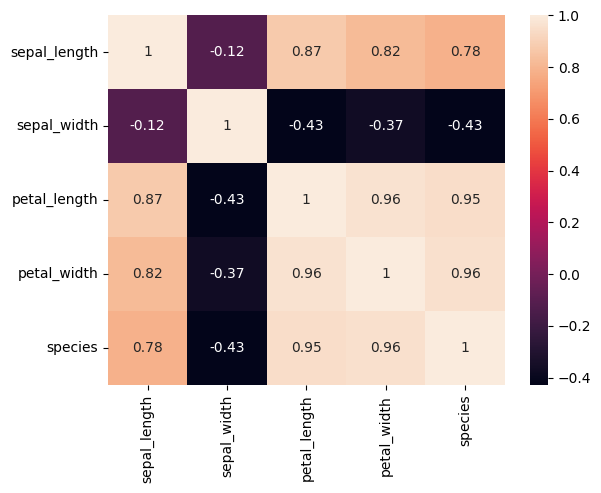

In [137]:
sns.heatmap(df.corr(), annot=True)
plt.show()

**Model Training and Evaluation**

In [138]:
x = df.drop('species', axis=1)

In [139]:
x

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [140]:
y = df['species']

In [141]:
y

,species
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [142]:
from sklearn.model_selection import train_test_split

In [143]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.75, random_state=42)


In [144]:
from sklearn.tree import DecisionTreeClassifier

In [145]:
model=DecisionTreeClassifier()

In [146]:
model.fit(x_train,y_train)

DecisionTreeClassifier()

In [147]:
result=pd.DataFrame()

In [148]:
result['actual']=y_test

In [149]:
y_pred=model.predict(x_test)

In [150]:
result["predicted"]=y_pred

In [151]:
result

,actual,predicted
73,1,1
18,0,0
118,2,2
78,1,1
76,1,1
31,0,0
64,1,1
141,2,2
68,1,1
82,1,1


In [152]:
from sklearn.metrics import accuracy_score
print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 1.0


In [153]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]


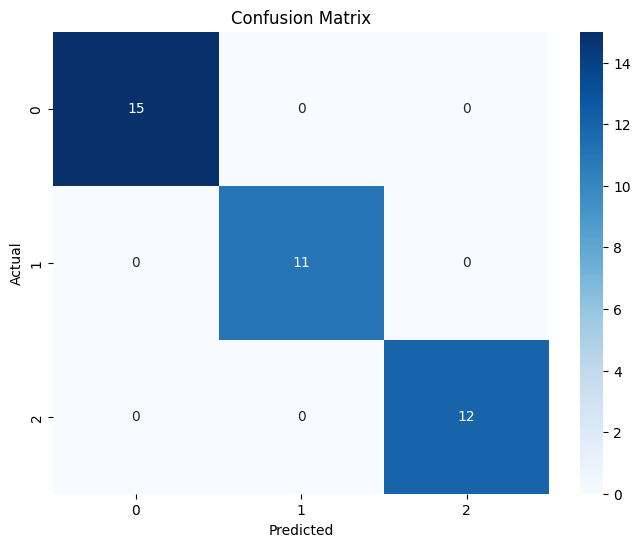

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=model.classes_,yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [155]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        12

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



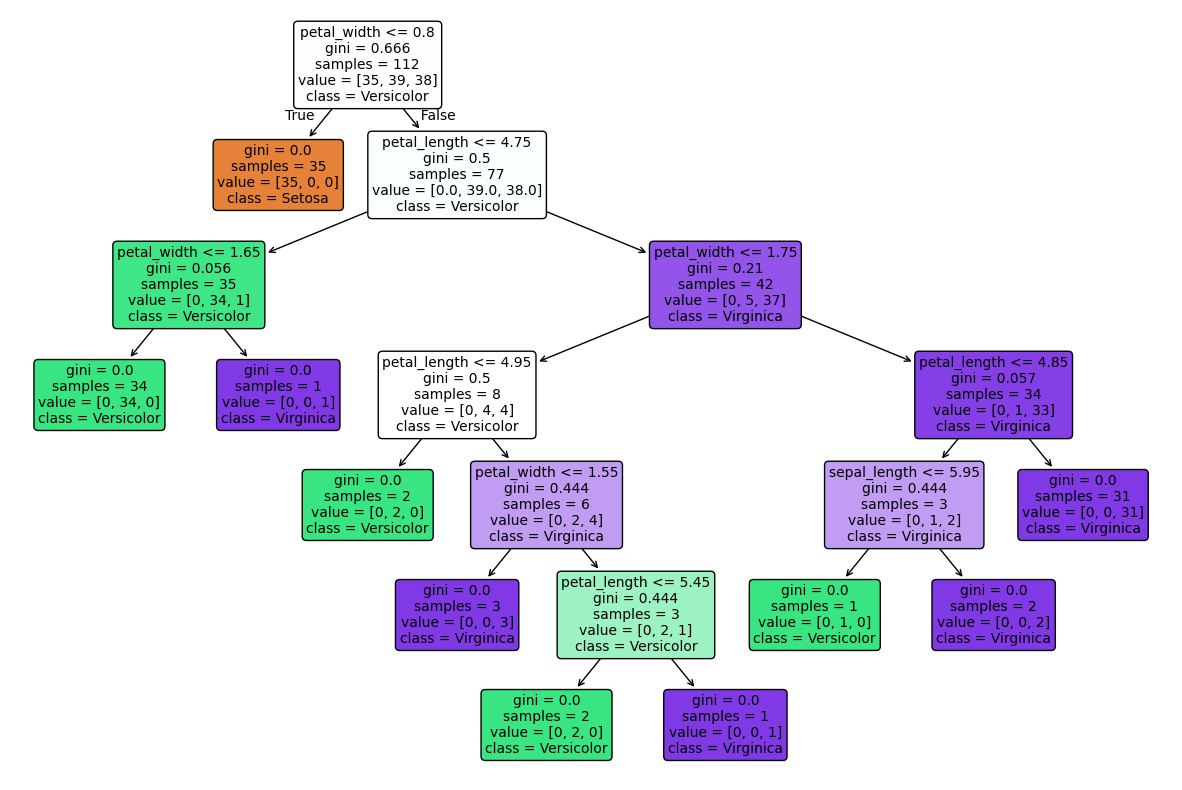

In [156]:
from sklearn.tree import plot_tree

plt.figure(figsize=(15,10))
plot_tree(model,feature_names=x.columns,class_names=['Setosa','Versicolor','Virginica'],filled=True,rounded=True)
plt.show()

In [157]:
tuned_model = DecisionTreeClassifier(max_depth=3, criterion='entropy')
tuned_model.fit(x_train, y_train)
print("Tuned Model Accuracy:", tuned_model.score(x_test, y_test))

Tuned Model Accuracy: 0.9736842105263158


In [158]:
importance = model.feature_importances_
for i, v in enumerate(importance):
    print(f"{x.columns[i]}: {v}")

sepal_length: 0.01787566834251057
sepal_width: 0.0
petal_length: 0.4158189081452329
petal_width: 0.5663054235122565


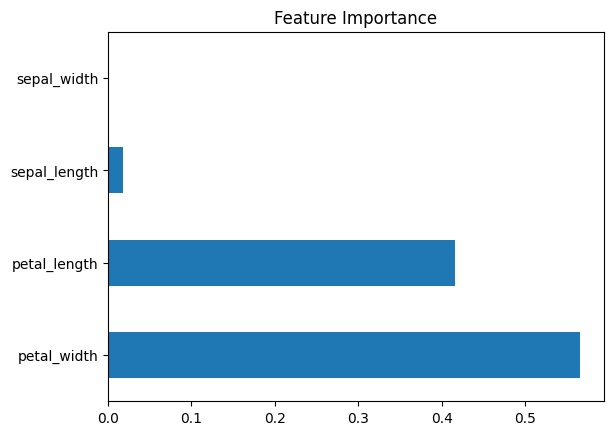

In [159]:
features = pd.Series(model.feature_importances_, index=x.columns)
features.nlargest(4).plot(kind='barh')
plt.title('Feature Importance')
plt.show()

**CONCLUSION**

 **Accuracy**: State the overall accuracy from your report.


**Key Features**: Mention which features (like petal length or width) were most important based on the feature_importances_ code you already have.


**Observation**: Note if the model struggled with any specific category.